# Compare neural operators for hyperelasticity problem

Run in **`neuralopv2`** after training DeepONet, PCANet, and FNO.

This notebook:
1. Loads the true hyperelasticity model and NOP surrogates via `nn_util.load_surrogate_model`
2. **In-distribution:** evaluates all test samples in latent and physical space
3. **Out-of-distribution:** samples a new prior and compares surrogate vs true forward model
4. Saves stats and sample plots under `compare_nops/in_distribution/` and `compare_nops/out_of_distribution/`
5. Builds 5×4 montage figures (m, True, DeepONet, PCANet, FNO) from saved PNGs


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI

from PIL import Image

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "..", "..", ".."))
MODEL_DIR = os.path.join(ROOT, "survey_work/problems/hyperelasticity")

sys.path.insert(0, os.path.join(ROOT, "src/plotting"))
sys.path.insert(0, os.path.join(ROOT, "src/data"))
sys.path.insert(0, os.path.join(ROOT, "src/prior"))
sys.path.insert(0, os.path.join(ROOT, "src/mcmc"))
sys.path.insert(0, os.path.join(ROOT, "src/nn"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/deeponet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/mlp"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/pcanet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/fno"))
sys.path.insert(0, MODEL_DIR)

from field_plot import quick_field_plot, quick_field_plot_grid
from hyperelasticityModel import HyperelasticityModel
from priorSampler import PriorSampler
from nn_util import load_surrogate_model

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)
torch.manual_seed(seed);

In [2]:
def get_ood_params(flag = 'Case_1'):
    if flag == 'Case_1':
        prior_ac_ood = 0.005
        prior_cc_ood = 0.2
        prior_logn_scale_ood = 100.0
        prior_logn_translate_ood = 1500.0
    elif flag == 'Case_2':
        prior_ac_ood = 0.005
        prior_cc_ood = 0.2
        prior_logn_scale_ood = 1000.0
        prior_logn_translate_ood = 1000.0
    else:
        raise ValueError(f"Invalid flag: {flag}")
    return prior_ac_ood, prior_cc_ood, prior_logn_scale_ood, prior_logn_translate_ood

In [3]:
# --- configuration ---
DATA_PREFIX = "Hyperelasticity"
NOP_NAMES = ("DeepONet", "PCANet", "FNO")
U_COMPS = 2

# Prior used to generate training / test data (in-distribution)
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 100.
prior_logn_translate = 1000.

# OOD prior (change these to explore generalization)
ood_case = 'Case_2'
prior_ac_ood, prior_cc_ood, prior_logn_scale_ood, prior_logn_translate_ood = get_ood_params(ood_case)
n_ood_samples = 100

# Test indices for sample plots (indices into each NOP test set)
i_choices = [27, 47, 43, 80, 5]
n_montage_samples = 4
montage_row_labels = [r"Input $m$", "True", "DeepONet", "PCANet", "FNO"]
montage_row_label_colors = ["black", "#f68612", "#176fc1", "#139a51", "#ec1c24"]

# Output directories
analysis_root = os.path.join(NOTEBOOK_DIR, "in_distribution")
ood_root = os.path.join(
    NOTEBOOK_DIR,
    "out_of_distribution",
    f"ood_case_{ood_case}_prior_ac_{prior_ac_ood:g}_cc_{prior_cc_ood:g}_ln_scale_{prior_logn_scale_ood:g}_ln_translate_{prior_logn_translate_ood:g}",
)
for d in (
    os.path.join(analysis_root, "stats"),
    os.path.join(analysis_root, "plots", "samples"),
    os.path.join(ood_root, "stats"),
    os.path.join(ood_root, "plots", "samples"),
    os.path.join(analysis_root, "plots"),
    os.path.join(ood_root, "plots"),
):
    os.makedirs(d, exist_ok=True)


## True Hyperelasticity model and NOP surrogates

In [4]:
nx, ny = 50, 50
fe_order = 1

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = functionspace(domain, ("Lagrange", fe_order, (2,)))

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)
model = HyperelasticityModel(
    Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed
)
nodes = model.m_nodes

surrogates = {}
for name in NOP_NAMES:
    sm = load_surrogate_model(name, DATA_PREFIX, MODEL_DIR, model, u_comps=U_COMPS)
    if sm is not None:
        surrogates[name] = sm
    else:
        print(f"{name} surrogate not loaded")

if not surrogates:
    raise RuntimeError("No surrogate models loaded")

u_mesh_dirichlet_boundary_nodes = surrogates['DeepONet'].data.u_mesh_dirichlet_boundary_nodes


DeepONet nn_data:  <dataMethods.DataProcessor object at 0x328bbb7a0>
DeepONet nn_model:  DeepONet(
  (branch_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2601, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=200, bias=True)
    )
  )
  (trunk_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=100, bias=True)
    )
  )
)
PCANet nn_data:  <dataMethods.DataProcessor object at 0x3292d3020>
PCANet nn_model:  PCANet(
  (net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=200, out_features=300, bias=True)
      (1): Linear(in_features=300, out_features=300, bias=True)
      (2): Linear(in_features=300, out_features=100, bias=True)
    )
  )
)
FNO nn_data:  <dataMethods.DataProcessorFNO object at 0x32aac43e0>
FNO nn_

## Helpers

In [5]:
def apply_dirichlet_bc(u, bc_value, bc_node_ids, num_nodes=None):
    # FEniCSx P1 vector layout: [ux(v0), uy(v0), ux(v1), uy(v1), ...]
    if num_nodes is None:
        num_nodes = u.shape[0] // U_COMPS
    u_xy = u.reshape(num_nodes, U_COMPS)
    u_xy[bc_node_ids, :] = bc_value
    return u_xy.reshape(-1)


def apply_grid_dirichlet_bc(u, bc_value, bc_node_ids):
    u[bc_node_ids[:, 0], bc_node_ids[:, 1], 0] = bc_value
    u[bc_node_ids[:, 0], bc_node_ids[:, 1], 1] = bc_value
    return u


def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def rel_l2_rows(a, b):
    a = np.asarray(a).reshape(len(a), -1)
    b = np.asarray(b).reshape(len(b), -1)
    num = np.linalg.norm(a - b, axis=1)
    den = np.linalg.norm(a, axis=1)
    return num / (den + 1e-30)


def predict_latent(name, sm):
    data, nn = sm.data, sm.model
    if name == "DeepONet":
        return to_numpy(nn.predict(data.X_test, data.X_trunk))
    return to_numpy(nn.predict(data.X_test))


def decode_u_physical(name, sm, y_latent_row):
    data = sm.data
    y = np.asarray(y_latent_row)
    if name == "FNO":
        if y.ndim == 1:
            y = y.reshape(data.num_grid_x, data.num_grid_y, data.num_Y_components)
        u = np.asarray(data.decoder_Y(y))
        if u.ndim == 4:
            u = u[0, :, :, :]
        apply_grid_dirichlet_bc(u, 0.0, data.u_grid_dirichlet_boundary_nodes)
        return u
    if y.ndim == 1:
        y = y.reshape(1, -1)
    u = np.asarray(data.decoder_Y(y)).reshape(-1)
    apply_dirichlet_bc(u, 0.0, data.u_mesh_dirichlet_boundary_nodes, num_nodes=nodes.shape[0])
    return u


def physical_errors(name, sm, y_pred):
    data = sm.data
    y_true = to_numpy(data.Y_test)
    n = y_true.shape[0]
    errs = np.zeros(n)
    for i in range(n):
        u_true = decode_u_physical(name, sm, y_true[i])
        u_pred = decode_u_physical(name, sm, y_pred[i])
        errs[i] = np.linalg.norm(u_true - u_pred) / (np.linalg.norm(u_true) + 1e-30)
    return errs


def save_field_plot(
    name,
    sm,
    u,
    path,
    cmap="jet",
    is_displacement=False,
    add_displacement_to_nodes=False,
):
    plot_kwargs = dict(
        cmap=cmap,
        savefilename=path,
        show_plot=False,
        is_displacement=is_displacement,
        add_displacement_to_nodes=add_displacement_to_nodes,
        vector_layout="mixed",
    )
    if name == "FNO":
        grid_x = sm.data.grid_x_test[0, :, :, 0]
        grid_y = sm.data.grid_y_test[0, :, :, 0]
        quick_field_plot_grid(u, grid_x, grid_y, **plot_kwargs)
    else:
        quick_field_plot(u, nodes, **plot_kwargs)
    plt.close()


def format_pct_error(err):
    return rf"$e = {100 * err:3.2f}\,\%$"


def render_cell_title(text, width, color, fontsize=20):
    from io import BytesIO

    dpi = 150
    fig, ax = plt.subplots(figsize=(width / dpi, 0.35), dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(0.5, 0.5, text, ha="center", va="center", fontsize=fontsize, color=color)
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, facecolor="white", edgecolor="none", bbox_inches="tight", pad_inches=0.02)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def render_row_label(text, label_w, cell_h, fontsize=22, color="black"):
    from io import BytesIO

    dpi = 150
    fig, ax = plt.subplots(figsize=(label_w / dpi, cell_h / dpi), dpi=dpi)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.text(
        0.5, 0.5, text,
        rotation=90, ha="center", va="center",
        fontsize=fontsize, color=color,
    )
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, facecolor="white", edgecolor="none")
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGB")


def save_image_montage(
    row_paths,
    save_path,
    pad=4,
    row_labels=None,
    row_label_colors=None,
    cell_titles=None,
    cell_title_colors=None,
    label_w=72,
    label_pad=4,
    label_fontsize=40,
    title_fontsize=28,
    title_x_shift=-40,
    title_y_shift=0,
):
    """Uniform a×a grid; each image centered at native size (no scaling)."""
    def load_rgb(path):
        im = Image.open(path)
        if im.mode == "RGBA":
            bg = Image.new("RGB", im.size, (255, 255, 255))
            bg.paste(im, mask=im.split()[3])
            return bg
        return im.convert("RGB")

    all_imgs = [load_rgb(p) for row in row_paths for p in row]
    a = max(max(im.size) for im in all_imgs)

    nrow = len(row_paths)
    ncol = len(row_paths[0])
    left_margin = (label_w + label_pad) if row_labels else 0
    montage = Image.new(
        "RGB",
        (left_margin + ncol * a + pad * (ncol - 1), nrow * a + pad * (nrow - 1)),
        (255, 255, 255),
    )

    if row_labels:
        if len(row_labels) != nrow:
            raise ValueError("row_labels must match number of rows")
        if row_label_colors is None:
            row_label_colors = ["black"] * nrow
        elif len(row_label_colors) != nrow:
            raise ValueError("row_label_colors must match number of rows")
        for r, text in enumerate(row_labels):
            label_im = render_row_label(
                text, label_w, a, fontsize=label_fontsize, color=row_label_colors[r],
            )
            montage.paste(label_im, (0, r * (a + pad)))

    for r, paths in enumerate(row_paths):
        for c, path in enumerate(paths):
            im = load_rgb(path)
            cell = Image.new("RGB", (a, a), (255, 255, 255))
            x_off = (a - im.width) // 2
            y_off = (a - im.height) // 2
            cell.paste(im, (x_off, y_off))

            if cell_titles is not None and cell_titles[r][c] is not None:
                color = "black"
                if cell_title_colors is not None and cell_title_colors[r][c] is not None:
                    color = cell_title_colors[r][c]
                title_im = render_cell_title(
                    cell_titles[r][c], im.width, color, fontsize=title_fontsize,
                )
                title_y = max(0, y_off - title_im.height - 2) + title_y_shift
                title_x = x_off + (im.width - title_im.width) // 2 + title_x_shift
                cell.paste(title_im, (title_x, title_y))

            montage.paste(cell, (left_margin + c * (a + pad), r * (a + pad)))

    montage.save(save_path)


## 1. In-distribution evaluation (test set)

In [6]:
in_dist_stats = {}

for name, sm in surrogates.items():
    print(f"\n=== {name} in-distribution ===")
    y_pred = predict_latent(name, sm)
    y_true = to_numpy(sm.data.Y_test)

    err_latent = rel_l2_rows(y_true, y_pred)
    err_physical = physical_errors(name, sm, y_pred)

    in_dist_stats[name] = {
        "latent": err_latent,
        "physical": err_physical,
    }

    print(
        f"Latent   rel L2: mean={err_latent.mean():.3e}, std={err_latent.std():.3e}"
    )
    print(
        f"Physical rel L2: mean={err_physical.mean():.3e}, std={err_physical.std():.3e}"
    )

stats_dir = os.path.join(analysis_root, "stats")
np.savez(
    os.path.join(stats_dir, "errors.npz"),
    **{f"{k}_latent": v["latent"] for k, v in in_dist_stats.items()},
    **{f"{k}_physical": v["physical"] for k, v in in_dist_stats.items()},
)

with open(os.path.join(stats_dir, "summary.txt"), "w") as f:
    for name, d in in_dist_stats.items():
        f.write(
            f"{name}: latent mean={d['latent'].mean():.6e} std={d['latent'].std():.6e}\n"
        )
        f.write(
            f"{name}: physical mean={d['physical'].mean():.6e} std={d['physical'].std():.6e}\n"
        )



=== DeepONet in-distribution ===
Latent   rel L2: mean=8.205e-02, std=4.041e-02
Physical rel L2: mean=3.219e-04, std=6.004e-05

=== PCANet in-distribution ===
Latent   rel L2: mean=2.135e-02, std=1.078e-02
Physical rel L2: mean=7.282e-05, std=3.275e-05

=== FNO in-distribution ===
Latent   rel L2: mean=5.162e-02, std=2.079e-02
Physical rel L2: mean=2.693e-04, std=1.017e-04


### Sample plots (in-distribution)

In [7]:
plot_dir = os.path.join(analysis_root, "plots", "samples")
cmaps = ["jet", "jet", "hot"]
plt.ioff()

# Use DeepONet data for shared m / true u on mesh (all NOPs share same test split)
ref_name = "DeepONet" if "DeepONet" in surrogates else next(iter(surrogates))
ref_sm = surrogates[ref_name]
y_true_ref = to_numpy(ref_sm.data.Y_test)

for i in i_choices:
    print(f"i = {i}")

    i_m = ref_sm.data.decoder_X(to_numpy(ref_sm.data.X_test[i]))
    save_field_plot(ref_name, ref_sm, np.asarray(i_m).reshape(-1), f"{plot_dir}/m_{i}.png", cmaps[0])

    i_u = decode_u_physical(ref_name, ref_sm, y_true_ref[i])
    save_field_plot(
        ref_name, ref_sm, i_u, f"{plot_dir}/u_{i}.png", cmaps[1],
        is_displacement=True, add_displacement_to_nodes=True,
    )

    for name, sm in surrogates.items():
        y_pred = predict_latent(name, sm)
        i_u_pred = decode_u_physical(name, sm, y_pred[i])
        save_field_plot(
            name, sm, i_u_pred, f"{plot_dir}/u_{name.lower()}_{i}.png", cmaps[1],
            is_displacement=True, add_displacement_to_nodes=True,
        )

        if name == "FNO":
            i_u_true_grid = decode_u_physical(name, sm, to_numpy(sm.data.Y_test[i]))
            err_field = i_u_true_grid - i_u_pred
        else:
            err_field = i_u - i_u_pred
        save_field_plot(
            name, sm, err_field, f"{plot_dir}/u_{name.lower()}_error_{i}.png", cmaps[2],
            is_displacement=True, add_displacement_to_nodes=False,
        )

        err_norm = in_dist_stats[name]["physical"][i]
        np.savetxt(f"{plot_dir}/u_{name.lower()}_error_norm_{i}.txt", [err_norm])


i = 27
i = 47
i = 43
i = 80
i = 5


### Montage (in-distribution)

Saved /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/problems/hyperelasticity/compare_with_linear_elasticity/in_distribution/plots/compare_nops_montage.png


(np.float64(-0.5), np.float64(2347.5), np.float64(2840.5), np.float64(-0.5))

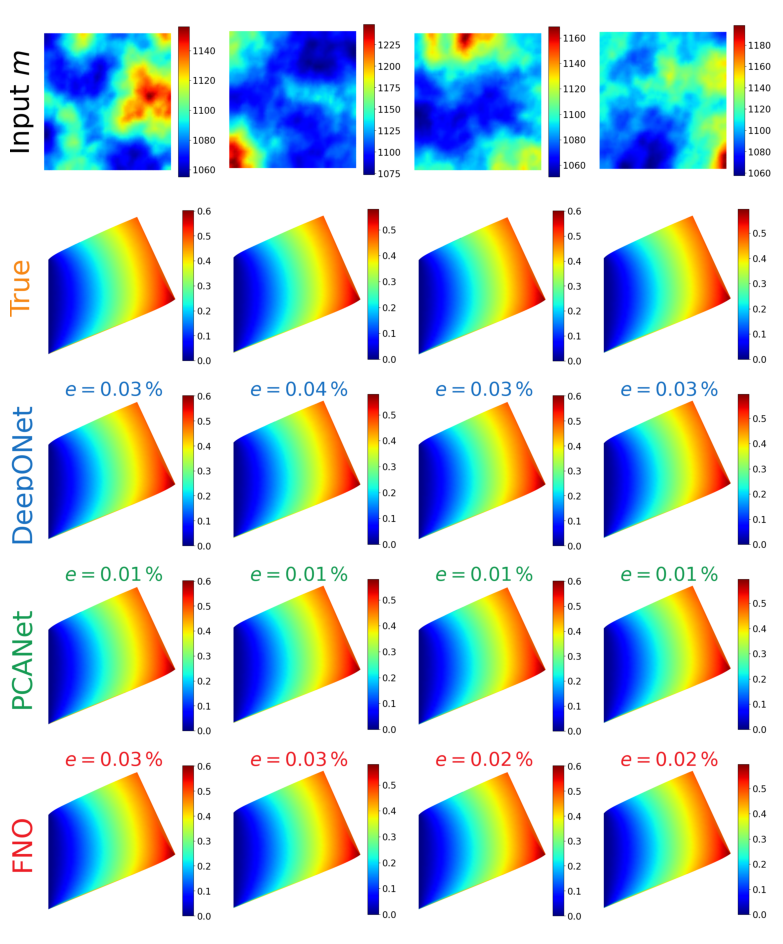

In [8]:
montage_indices = i_choices[:n_montage_samples]

row_paths = [
    [f"{plot_dir}/m_{i}.png" for i in montage_indices],
    [f"{plot_dir}/u_{i}.png" for i in montage_indices],
    [f"{plot_dir}/u_deeponet_{i}.png" for i in montage_indices],
    [f"{plot_dir}/u_pcanet_{i}.png" for i in montage_indices],
    [f"{plot_dir}/u_fno_{i}.png" for i in montage_indices],
]

blank = [None] * n_montage_samples
cell_titles = [
    blank,
    blank,
    [format_pct_error(in_dist_stats["DeepONet"]["physical"][i]) for i in montage_indices],
    [format_pct_error(in_dist_stats["PCANet"]["physical"][i]) for i in montage_indices],
    [format_pct_error(in_dist_stats["FNO"]["physical"][i]) for i in montage_indices],
]
cell_title_colors = [
    blank,
    blank,
    [montage_row_label_colors[2]] * n_montage_samples,
    [montage_row_label_colors[3]] * n_montage_samples,
    [montage_row_label_colors[4]] * n_montage_samples,
]

montage_path = os.path.join(analysis_root, "plots", "compare_nops_montage.png")
save_image_montage(
    row_paths,
    montage_path,
    row_labels=montage_row_labels,
    row_label_colors=montage_row_label_colors,
    cell_titles=cell_titles,
    cell_title_colors=cell_title_colors,
)
print(f"Saved {montage_path}")

# display the montage
img = Image.open(montage_path)

# Set display window size in inches (Width, Height)
plt.figure(figsize=(20, 12))

# Display the Pillow image inside Matplotlib
plt.imshow(img)
plt.axis("off")  # Hide grid coordinates

## 2. Out-of-distribution evaluation (new prior)

In [9]:
prior_ood = PriorSampler(Vm, prior_ac_ood, prior_cc_ood, seed + 1)

# Shared by model and all surrogates (sm.true_model -> same object).
model.logn_scale = prior_logn_scale_ood
model.logn_translate = prior_logn_translate_ood

ood_stats = {name: np.zeros(n_ood_samples) for name in surrogates}

print(f"OOD prior: ac={prior_ac_ood}, cc={prior_cc_ood}, n={n_ood_samples}")
t0 = time.time()

for k in range(n_ood_samples):
    w = prior_ood()[0]
    m = model.transform_gaussian_pointwise(w)
    u_true = model.solveFwd(u=None, m=m, transform_m=False)
    
    for name, sm in surrogates.items():
        u_pred = sm.solveFwd(w)
        ood_stats[name][k] = np.linalg.norm(u_true - u_pred) / (np.linalg.norm(u_true) + 1e-30)

    if (k + 1) % max(1, n_ood_samples // 10) == 0:
        print(f"  OOD sample {k + 1}/{n_ood_samples}")

print(f"OOD finished in {time.time() - t0:.1f}s")

ood_stats_dir = os.path.join(ood_root, "stats")
np.savez(os.path.join(ood_stats_dir, "errors.npz"), **ood_stats)

with open(os.path.join(ood_stats_dir, "summary.txt"), "w") as f:
    f.write(f"prior_ac={prior_ac_ood}, prior_cc={prior_cc_ood}, n={n_ood_samples}\n")
    for name, errs in ood_stats.items():
        f.write(f"{name}: mean={errs.mean():.6e} std={errs.std():.6e}\n")
        print(f"{name} OOD rel L2: mean={errs.mean():.3e}, std={errs.std():.3e}")


OOD prior: ac=0.005, cc=0.2, n=100


ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniforge/base/envs/neuralopv2/lib' ignored
ld: warning: duplicate -rpath '/opt/homebrew/Caskroom/miniforge/base/envs/neuralopv2/lib' ignored


  OOD sample 10/100
  OOD sample 20/100
  OOD sample 30/100
  OOD sample 40/100
  OOD sample 50/100
  OOD sample 60/100
  OOD sample 70/100
  OOD sample 80/100
  OOD sample 90/100
  OOD sample 100/100
OOD finished in 83.9s
DeepONet OOD rel L2: mean=5.265e-01, std=1.359e-01
PCANet OOD rel L2: mean=5.297e-01, std=1.361e-01
FNO OOD rel L2: mean=6.921e-01, std=1.696e-01


### Sample plots (OOD)

In [10]:
ood_plot_dir = os.path.join(ood_root, "plots", "samples")

for j in i_choices:
    w = prior_ood()[0]
    m = model.transform_gaussian_pointwise(w)
    u_true = model.solveFwd(u=None, m=m, transform_m=False)

    quick_field_plot(m, nodes, cmap="jet", savefilename=f"{ood_plot_dir}/m_ood_{j}.png", show_plot=False)
    plt.close()
    quick_field_plot(
        u_true, nodes, cmap="jet", savefilename=f"{ood_plot_dir}/u_true_ood_{j}.png", show_plot=False,
        is_displacement=True, add_displacement_to_nodes=True, vector_layout="mixed",
    )
    plt.close()

    for name, sm in surrogates.items():
        u_pred = sm.solveFwd(w)
        quick_field_plot(
            u_pred, nodes, cmap="jet", savefilename=f"{ood_plot_dir}/u_{name.lower()}_ood_{j}.png", show_plot=False,
            is_displacement=True, add_displacement_to_nodes=True, vector_layout="mixed",
        )
        plt.close()
        err = u_true - u_pred
        quick_field_plot(
            err, nodes, cmap="hot", savefilename=f"{ood_plot_dir}/u_{name.lower()}_error_ood_{j}.png", show_plot=False,
            is_displacement=True, add_displacement_to_nodes=False, vector_layout="mixed",
        )
        plt.close()

print(f"OOD sample plots saved to {ood_plot_dir}")


OOD sample plots saved to /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/problems/hyperelasticity/compare_with_linear_elasticity/out_of_distribution/ood_case_Case_2_prior_ac_0.005_cc_0.2_ln_scale_1000_ln_translate_1000/plots/samples


### Montage (out-of-distribution)

DeepONet OOD rel L2: 0.37201850301233197
PCANet OOD rel L2: 0.37734710438206737
FNO OOD rel L2: 0.5376107341940038
DeepONet OOD rel L2: 0.5625057896356744
PCANet OOD rel L2: 0.5674363621469748
FNO OOD rel L2: 0.6199831756799741
DeepONet OOD rel L2: 0.5058245976824425
PCANet OOD rel L2: 0.5119080970976959
FNO OOD rel L2: 0.7395000142998781
DeepONet OOD rel L2: 0.60470658647286
PCANet OOD rel L2: 0.6031323248926731
FNO OOD rel L2: 0.6466376285095885
Saved /Users/prashant/Dropbox/Work/Simulations/neuralnet_works/error_corrector_direction/neural_operators/survey_work/problems/hyperelasticity/compare_with_linear_elasticity/out_of_distribution/ood_case_Case_2_prior_ac_0.005_cc_0.2_ln_scale_1000_ln_translate_1000/plots/compare_nops_montage.png


(np.float64(-0.5), np.float64(2383.5), np.float64(2885.5), np.float64(-0.5))

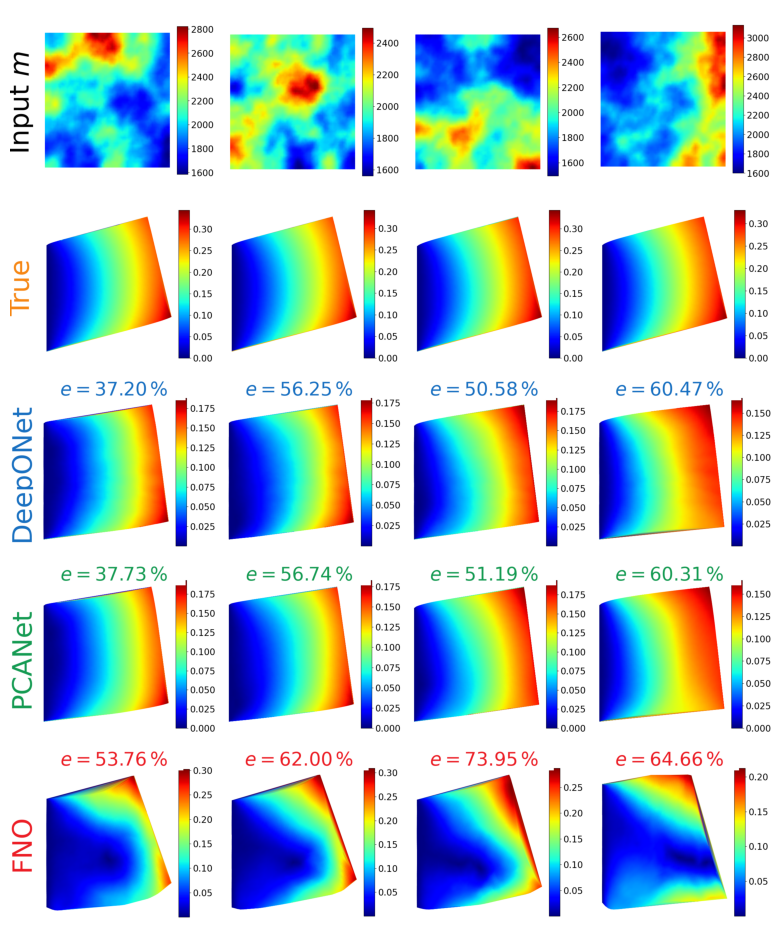

In [11]:
ood_montage_indices = i_choices[:n_montage_samples]
for i in ood_montage_indices:
    for name, sm in surrogates.items():
        ei = ood_stats[name][i]
        print(f"{name} OOD rel L2: {ei}")

ood_row_paths = [
    [f"{ood_plot_dir}/m_ood_{j}.png" for j in ood_montage_indices],
    [f"{ood_plot_dir}/u_true_ood_{j}.png" for j in ood_montage_indices],
    [f"{ood_plot_dir}/u_deeponet_ood_{j}.png" for j in ood_montage_indices],
    [f"{ood_plot_dir}/u_pcanet_ood_{j}.png" for j in ood_montage_indices],
    [f"{ood_plot_dir}/u_fno_ood_{j}.png" for j in ood_montage_indices],
]

blank = [None] * n_montage_samples
ood_cell_titles = [
    blank,
    blank,
    [format_pct_error(ood_stats["DeepONet"][j]) for j in ood_montage_indices],
    [format_pct_error(ood_stats["PCANet"][j]) for j in ood_montage_indices],
    [format_pct_error(ood_stats["FNO"][j]) for j in ood_montage_indices],
]
ood_cell_title_colors = [
    blank,
    blank,
    [montage_row_label_colors[2]] * n_montage_samples,
    [montage_row_label_colors[3]] * n_montage_samples,
    [montage_row_label_colors[4]] * n_montage_samples,
]

ood_montage_path = os.path.join(ood_root, "plots", "compare_nops_montage.png")
save_image_montage(
    ood_row_paths,
    ood_montage_path,
    row_labels=montage_row_labels,
    row_label_colors=montage_row_label_colors,
    cell_titles=ood_cell_titles,
    cell_title_colors=ood_cell_title_colors,
)
print(f"Saved {ood_montage_path}")

# display the montage
img = Image.open(ood_montage_path)

# Set display window size in inches (Width, Height)
plt.figure(figsize=(20, 12))

# Display the Pillow image inside Matplotlib
plt.imshow(img)
plt.axis("off")  # Hide grid coordinates